In [12]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [13]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [14]:
X_test[0].shape

(28, 28)

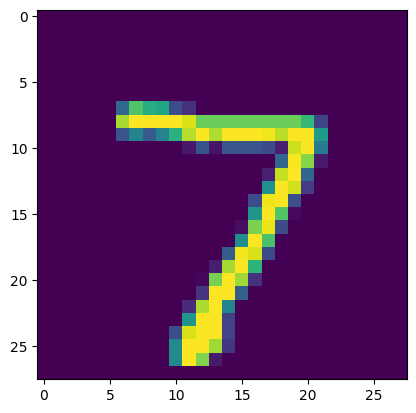

In [20]:
import matplotlib.pyplot as plt
plt.imshow(X_test[0])

In [6]:
X_train = X_train/255
X_test = X_test/255

In [7]:
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dropout
model = Sequential()


model.add(Input(shape=(28, 28)))
model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [11]:
history = model.fit(X_train, y_train, epochs=25, validation_split=0.2, callbacks=[early_stop])

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8081 - loss: 0.6243 - val_accuracy: 0.9552 - val_loss: 0.1480
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9458 - loss: 0.1778 - val_accuracy: 0.9636 - val_loss: 0.1211
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9567 - loss: 0.1380 - val_accuracy: 0.9682 - val_loss: 0.1038
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9641 - loss: 0.1150 - val_accuracy: 0.9697 - val_loss: 0.1008
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9682 - loss: 0.0974 - val_accuracy: 0.9728 - val_loss: 0.0923
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9703 - loss: 0.0897 - val_accuracy: 0.9739 - val_loss: 0.0883
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9738 - loss: 0.0794 - val_accuracy: 0.9732 - val_loss: 0.0924
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9765 - loss: 0.0755 - 

In [12]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [13]:
y_pred = y_prob.argmax(axis=1)

In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9774

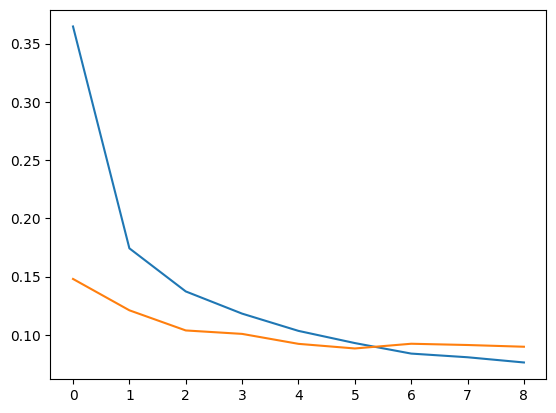

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

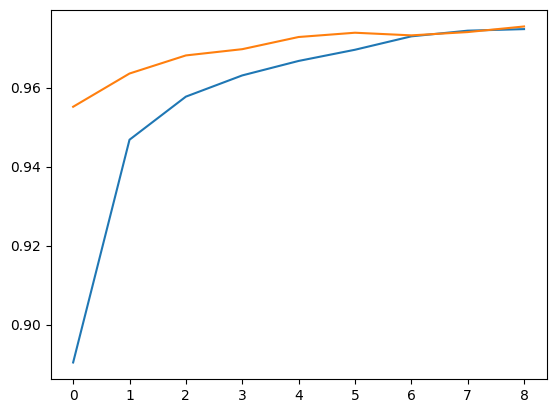

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

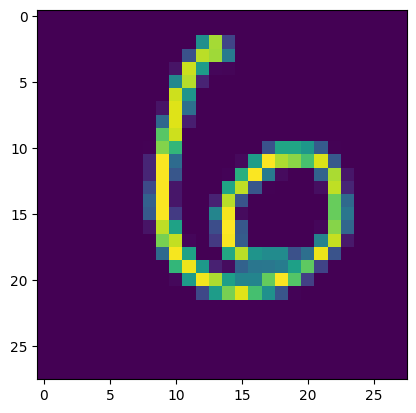

In [17]:
plt.imshow(X_test[100])

In [18]:
lmao=model.predict(X_test[100].reshape(1,28,28))
print(lmao)
print(lmao.argmax(axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
[[2.1316966e-05 4.2880497e-08 1.4401382e-06 1.5829659e-07 4.6595601e-06
  1.1450417e-05 9.9995124e-01 1.6422885e-06 7.9265419e-06 2.9644427e-09]]
[6]


In [19]:
model.save('are_yrr.h5')

In [11]:
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model("model.keras")

# Load and preprocess image
imgg = cv2.imread("seven.png")
# imgg=X_test[0] 
 
imgg = cv2.cvtColor(imgg, cv2.COLOR_BGR2GRAY)       # convert to grayscale
imgg = cv2.resize(imgg, (28, 28))
print("shape ",imgg.shape," size ",imgg.size )                # resize to 28x28
imgg = imgg / 255.0                                 # normalize
imgg = imgg.reshape(1,28,28,1)                    # reshape for model

# Predict
pred = model.predict(imgg)
print(f"Prediction: {pred}, Digit: {1+pred.argmax(axis=1)[0]}")

shape  (28, 28)  size  784
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Prediction: [[4.3294704e-10 1.4449016e-09 2.2411814e-11 4.2788101e-10 3.4259067e-13
  9.9237079e-13 1.0000000e+00 2.0558404e-10 1.1529145e-09]], Digit: 7
